In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset.csv to Dataset.csv


In [ ]:
df=pd.read_csv('Dataset.csv')

In [ ]:
df.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Review Rating'] = df['Review Rating'].fillna(
    df['Review Rating'].median()
)

37 missing values were identified in the Review Rating column.
Since missing reviews do not necessarily imply customer dissatisfaction,
median imputation was applied to preserve customer records while minimizing distortion from outliers.

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].value_counts())


 Gender
Gender
Male      2652
Female    1248
Name: count, dtype: int64

 Item Purchased
Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Sandals       160
Socks         159
Skirt         158
Scarf         157
Shorts        157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64

 Category
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

 Location
Location
Montana           96
California        95
Idaho             93
Illinois          92
Alabama           89
Minnesota         88
New York          87
Nevada            87
Nebraska          87
Delaware          86
Maryland          86
Vermont           85
Louisiana         84
N

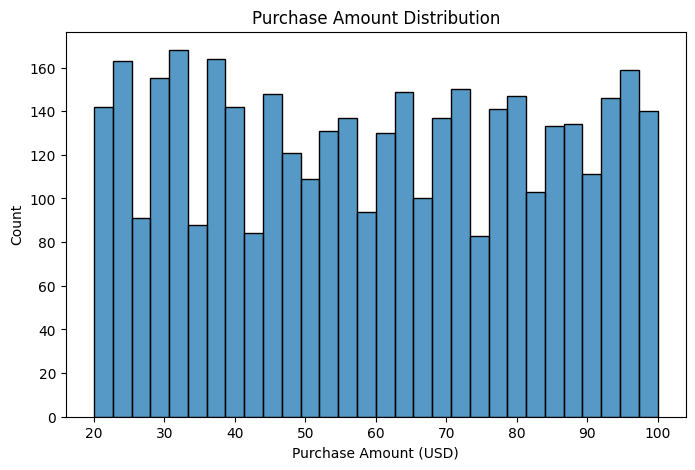

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Purchase Amount (USD)'], bins=30)
plt.title('Purchase Amount Distribution')
plt.show()

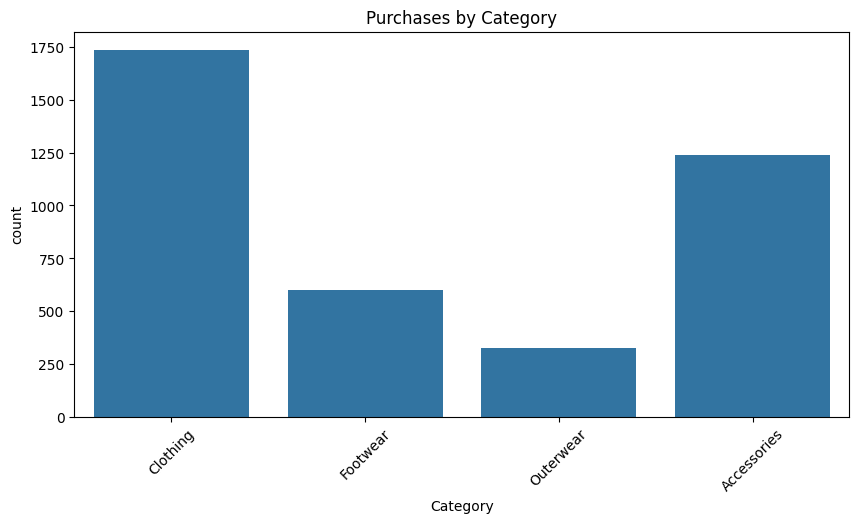

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Category', data=df)
plt.xticks(rotation=45)
plt.title('Purchases by Category')
plt.show()

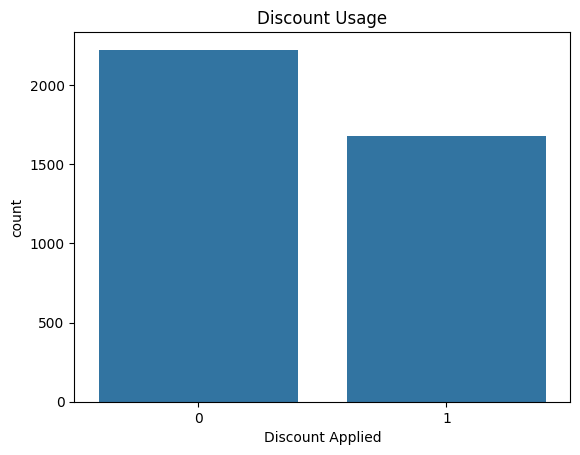

In [ ]:
sns.countplot(x='Discount Applied', data=df)
plt.title('Discount Usage')
plt.show()

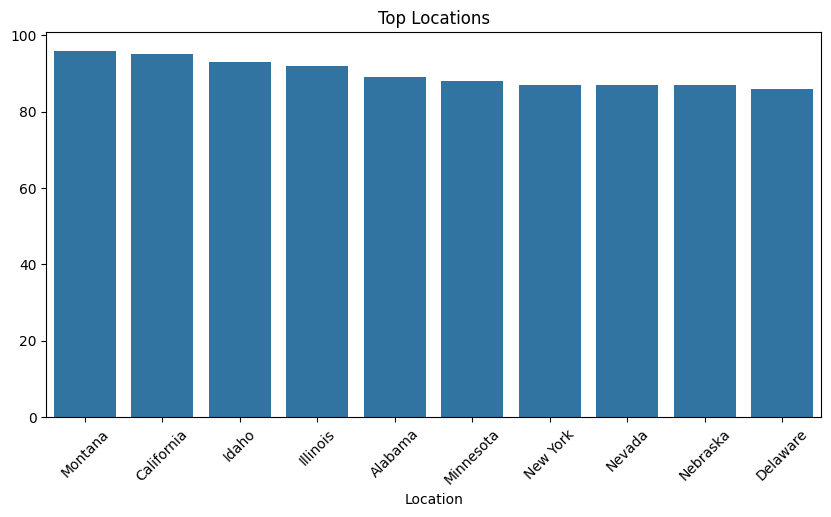

In [ ]:
top_locations = df['Location'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_locations.index, y=top_locations.values)
plt.xticks(rotation=45)
plt.title('Top Locations')
plt.show()

In [ ]:
df['Discount Applied'] = df['Discount Applied'].map({'Yes':1, 'No':0})
df['Promo Code Used'] = df['Promo Code Used'].map({'Yes':1, 'No':0})
df['Subscription Status'] = df['Subscription Status'].map({'Yes':1, 'No':0})

In [ ]:
customer_level = df.groupby('Customer ID').agg({
    'Age':'first',
    'Gender':'first',
    'Location':'first',
    'Purchase Amount (USD)':['sum','mean'],
    'Previous Purchases':'max',
    'Review Rating':'mean',
    'Discount Applied':'mean',
    'Promo Code Used':'mean',
    'Subscription Status':'mean'
}).reset_index()

In [ ]:
customer_level.columns = [
    'Customer_ID',
    'Age',
    'Gender',
    'Location',
    'Total_Spend',
    'Average_Order_Value',
    'Previous_Purchases',
    'Average_Rating',
    'Discount_Usage_Rate',
    'Promo_Usage_Rate',
    'Subscription_Rate'
]

In [ ]:
customer_level['Customer_Value_Tier'] = pd.qcut(
    customer_level['Total_Spend'],
    q=3,
    labels=['Low','Medium','High']
)

In [ ]:
customer_level.to_csv('customer_level_dataset.csv', index=False)

In [ ]:
customer_level.head(10)

,Customer_ID,Age,Gender,Location,Total_Spend,Average_Order_Value,Previous_Purchases,Average_Rating,Discount_Usage_Rate,Promo_Usage_Rate,Subscription_Rate,Customer_Value_Tier
0,1,55,Male,Kentucky,53,53.0,14,3.1,NaN,NaN,NaN,Medium
1,2,19,Male,Maine,64,64.0,2,3.1,NaN,NaN,NaN,Medium
2,3,50,Male,Massachusetts,73,73.0,23,3.1,NaN,NaN,NaN,Medium
3,4,21,Male,Rhode Island,90,90.0,49,3.5,NaN,NaN,NaN,High
4,5,45,Male,Oregon,49,49.0,31,2.7,NaN,NaN,NaN,Medium
5,6,46,Male,Wyoming,20,20.0,14,2.9,NaN,NaN,NaN,Low
6,7,63,Male,Montana,85,85.0,49,3.2,NaN,NaN,NaN,High
7,8,27,Male,Louisiana,34,34.0,19,3.2,NaN,NaN,NaN,Low
8,9,26,Male,West Virginia,97,97.0,8,2.6,NaN,NaN,NaN,High
9,10,57,Male,Missouri,31,31.0,4,4.8,NaN,NaN,NaN,Low


In [ ]:
customer_level['Promo_Dependency_Score'] = (
    customer_level['Discount_Usage_Rate'] * 0.6 +
    customer_level['Promo_Usage_Rate'] * 0.4
)

In [ ]:
customer_level['Loyalty_Score'] = (
    customer_level['Previous_Purchases'] * 0.5 +
    customer_level['Average_Rating'] * 0.3 +
    customer_level['Subscription_Rate'] * 0.2
)

In [ ]:
customer_level['High_Value_Customer'] = np.where(
    customer_level['Customer_Value_Tier']=='High',
    1,
    0
)

In [ ]:
customer_level['Satisfied_Customer'] = np.where(
    customer_level['Average_Rating'] >= 3.5,
    1,
    0
)

In [ ]:
customer_level['Loyal_Customer'] = np.where(
    (customer_level['Previous_Purchases'] > 20) &
    (customer_level['Promo_Dependency_Score'] < 0.5),
    1,
    0
)

In [ ]:
customer_level['At_Risk_Customer'] = np.where(
    (customer_level['Average_Rating'] < 3) |
    (customer_level['Promo_Dependency_Score'] > 0.8),
    1,
    0
)

In [ ]:
customer_level.to_csv('feature_engineered_customers.csv', index=False)

In [ ]:
customer_level.head()

,Customer_ID,Age,Gender,Location,Total_Spend,Average_Order_Value,Previous_Purchases,Average_Rating,Discount_Usage_Rate,Promo_Usage_Rate,Subscription_Rate,Customer_Value_Tier,Promo_Dependency_Score,Loyalty_Score,High_Value_Customer,Satisfied_Customer,Loyal_Customer,At_Risk_Customer
0,1,55,Male,Kentucky,53,53.0,14,3.1,NaN,NaN,NaN,Medium,NaN,NaN,0,0,0,0
1,2,19,Male,Maine,64,64.0,2,3.1,NaN,NaN,NaN,Medium,NaN,NaN,0,0,0,0
2,3,50,Male,Massachusetts,73,73.0,23,3.1,NaN,NaN,NaN,Medium,NaN,NaN,0,0,0,0
3,4,21,Male,Rhode Island,90,90.0,49,3.5,NaN,NaN,NaN,High,NaN,NaN,1,1,0,0
4,5,45,Male,Oregon,49,49.0,31,2.7,NaN,NaN,NaN,Medium,NaN,NaN,0,0,0,1
